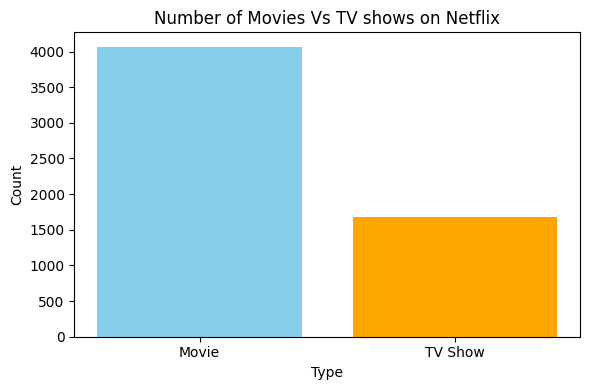

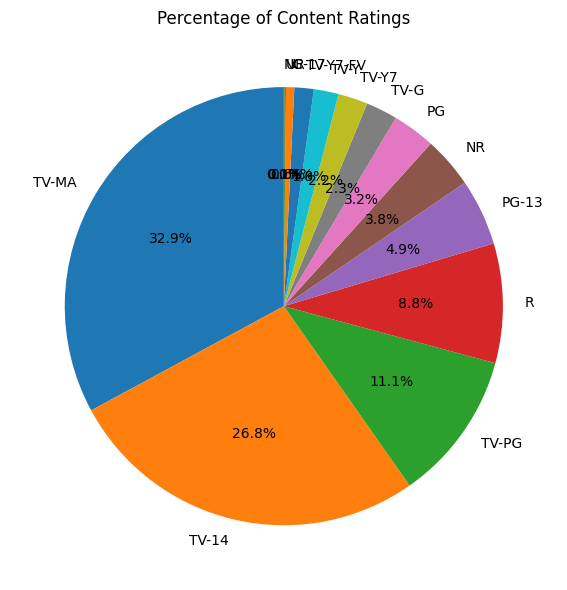

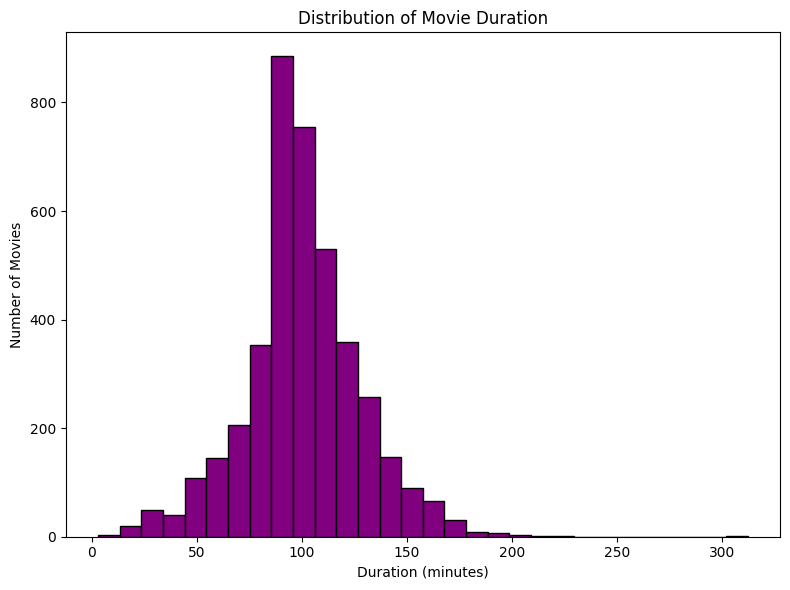

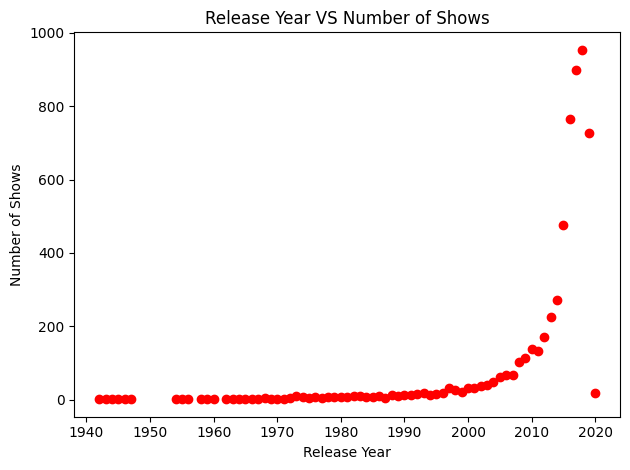

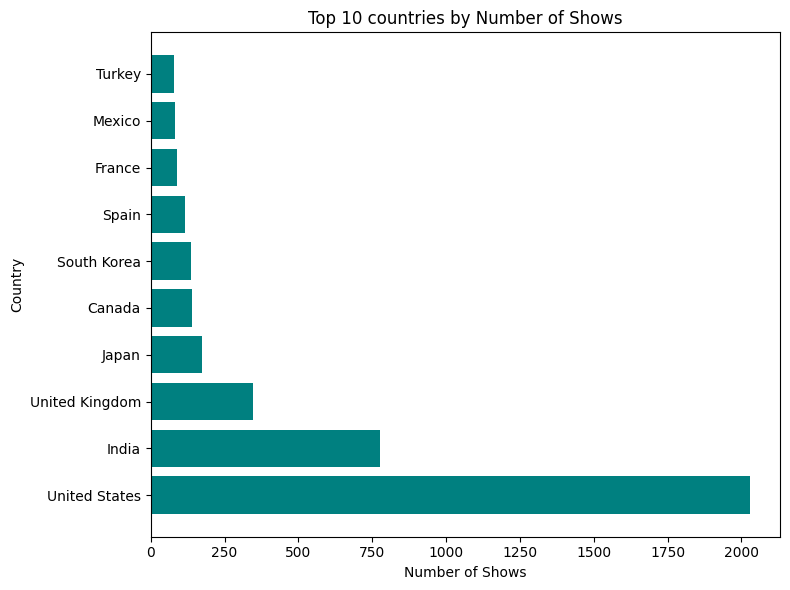

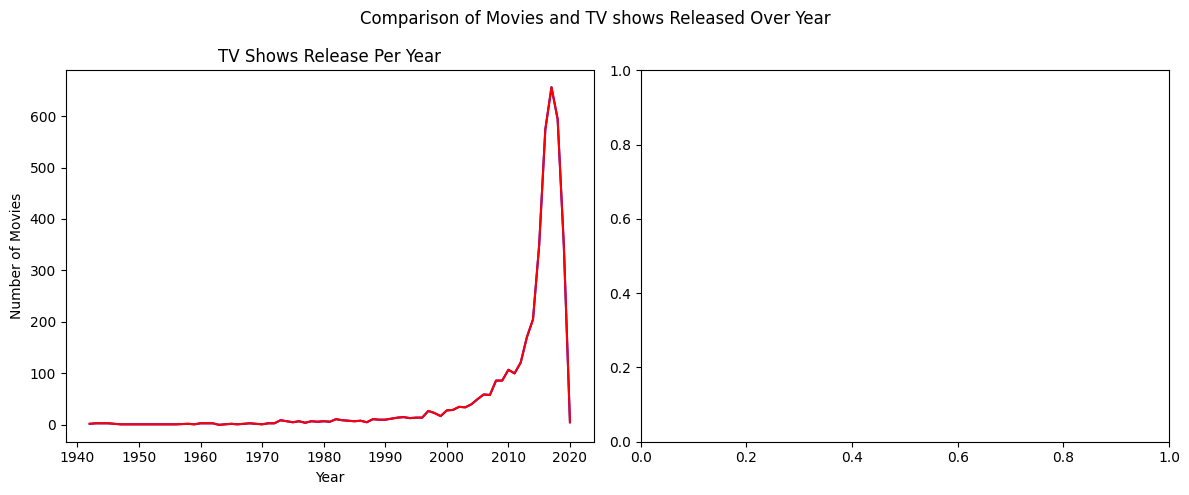

In [15]:
#s-1 import the libraries
import pandas as pd
import matplotlib.pyplot as plt


#load the data
df = pd.read_csv('NetflixCSV.csv')
# print(df.head())


#clean data
df = df.dropna(subset = ['type','release_year','rating','country','duration'])

# bar chart for number of movies vs tv shows on netflix
type_counts = df['type'].value_counts()
plt.figure(figsize= (6,4))
plt.bar(type_counts.index, type_counts.values,color=['skyblue','orange'])
plt.title('Number of Movies Vs TV shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

#Pie chart for rating
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels= rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('content_Ratings_pie.png')
plt.show()


#Histogram for Movies duration

movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min',' ').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color='purple',edgecolor= 'black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movies_duration_histogram.png')
plt.show()



#scatter plot for release_year vs no. of shows

release_counts = df['release_year'].value_counts().sort_index()
plt.Figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values,color = 'red')
plt.title('Release Year VS Number of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()




#horizontal bar chart for no of countries which have mmore no. of shows


country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color = 'teal')
plt.title('Top 10 countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()


#subplot for movies vs tv shows by year

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig , ax = plt.subplots(1,2, figsize= (12,5))

#first subplot:movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color= 'blue')
ax[0].set_title('Movies Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

#second subplot:TV shows
ax[0].plot(content_by_year.index, content_by_year['Movie'], color= 'red')
ax[0].set_title('TV Shows Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

fig.suptitle('Comparison of Movies and TV shows Released Over Year')

plt.tight_layout()
plt.savefig('movies_tvshows_comparison.png')
plt.show()
